# Palm Image Dataset — Exploratory Data Analysis

In [3]:
import os
import glob
import yaml
import random
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

In [4]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg
/kaggle/input/d

## MediaPipe Hands Reference
Link: https://github.com/google-ai-edge/mediapipe/blob/master/docs/solutions/hands.md

MediaPipe Hands will be used for palm/hand detection and landmark detection. It detects 21 hand landmarks and helps identify wrist, fingers, palm region, and hand orientation.

This will be used after EDA to check whether an image contains a detectable palm/hand or not.

In [5]:
!nvidia-smi

Sun Jul 26 07:30:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    if filenames:
        print(dirname, ":", len(filenames), "files")

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset : 1 files
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands : 11076 files


In [7]:
import os

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
image_files = []

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower().endswith(image_extensions):
            image_files.append(os.path.join(dirname, filename))

print("Total image files:", len(image_files))
print("First 10 image paths:")
for img in image_files[:10]:
    print(img)

Total image files: 11076
First 10 image paths:
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg


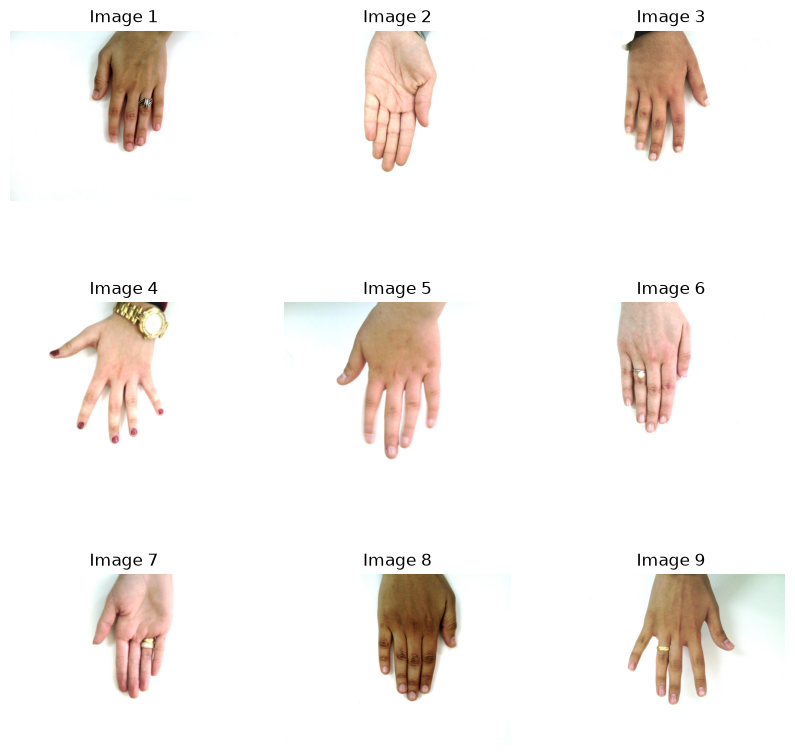

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

sample_images = image_files[:9]

plt.figure(figsize=(10, 10))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.show()

In [9]:
import pandas as pd
from PIL import Image

image_info = []

for img_path in image_files[:500]:
    img = Image.open(img_path)
    image_info.append({
        "file_path": img_path,
        "width": img.size[0],
        "height": img.size[1],
        "mode": img.mode
    })

df = pd.DataFrame(image_info)
df.head()

,file_path,width,height,mode
0,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
1,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
2,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
3,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB
4,/kaggle/input/datasets/shyambhu/hands-and-palm...,1600,1200,RGB


In [10]:
df[['width', 'height']].describe()

,width,height
count,500.0,500.0
mean,1600.0,1200.0
std,0.0,0.0
min,1600.0,1200.0
25%,1600.0,1200.0
50%,1600.0,1200.0
75%,1600.0,1200.0
max,1600.0,1200.0


# EDA Findings

I downloaded/added the Hands and Palm Images Dataset in Kaggle Notebook and performed initial EDA.

## Work Done
- Checked dataset file structure.
- Counted total image files.
- Displayed sample palm/hand images.
- Checked image size, width, height, and image format.

## Findings
- The dataset contains hand and palm images.
- The images are useful for palm image preprocessing, palm detection, and feature extraction.
- Some images may need preprocessing such as resizing, grayscale conversion, contrast enhancement, and noise removal before further analysis.

## Next Step
The next step is to build a palm image detector to check whether an uploaded image contains a palm/hand or not.

# Palm Image Detection

After completing EDA, the next step is to check whether an image contains a detectable palm/hand or not. For this, MediaPipe Hands will be used.

In [11]:
!pip install mediapipe opencv-python

In [12]:
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

image_files = []

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower().endswith(image_extensions):
            image_files.append(os.path.join(dirname, filename))

print("Total images found:", len(image_files))
print(image_files[:5])

Total images found: 11076
['/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg', '/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg']


In [13]:
!pip install --upgrade --force-reinstall protobuf==4.25.8
!pip install --upgrade --force-reinstall mediapipe==0.10.14

  Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.8-cp37-abi3-manylinux2014_x86_64.whl (294 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
a2a-sdk 0.3.26 requires protobuf>=5.29.5, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto

In [14]:
import google.protobuf
print("Protobuf version:", google.protobuf.__version__)

Protobuf version: 4.25.9


In [15]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14 opencv-python

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)
Using cached matplotlib-3.11.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.11.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.5.1 w

In [18]:
!pip uninstall -y tensorflow tensorflow-cpu tensorflow-gpu tf-nightly

In [19]:
!pip uninstall -y protobuf mediapipe
!pip install protobuf==4.25.9
!pip install mediapipe==0.10.14 opencv-python

Found existing installation: protobuf 4.25.9
Uninstalling protobuf-4.25.9:
  Successfully uninstalled protobuf-4.25.9
Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl (295 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
bigframes 2.39.0 requires matplotlib>=3.7.1, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
grpcio-tools 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
a2a-sdk 0.3.26 requires protobuf>=5.29.5, but you have protobu

In [20]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import os
from PIL import Image

print("MediaPipe version:", mp.__version__)

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("MediaPipe imported successfully")

MediaPipe version: 0.10.14
MediaPipe imported successfully


In [16]:
def detect_palm(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return "Image not loaded", None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5
    ) as hands:

        results = hands.process(image_rgb)

        if results.multi_hand_landmarks:
            output_image = image_rgb.copy()

            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    output_image,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS
                )

            return "Palm Detected", output_image
        else:
            return "Palm Not Detected", image_rgb

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785051067.041768     394 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051067.078314     394 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Result: Palm Detected


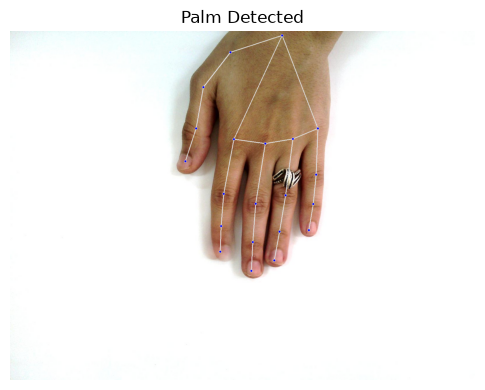

In [17]:
test_image = image_files[0]

result, output = detect_palm(test_image)

print("Result:", result)

plt.figure(figsize=(6, 6))
plt.imshow(output)
plt.axis("off")
plt.title(result)
plt.show()

W0000 00:00:1785051158.860893     434 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051158.892939     434 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051158.987351     436 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051159.015647     436 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051159.098380     442 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051159.114308     442 inference_feedback_manager.cc:114] Feedback manager 

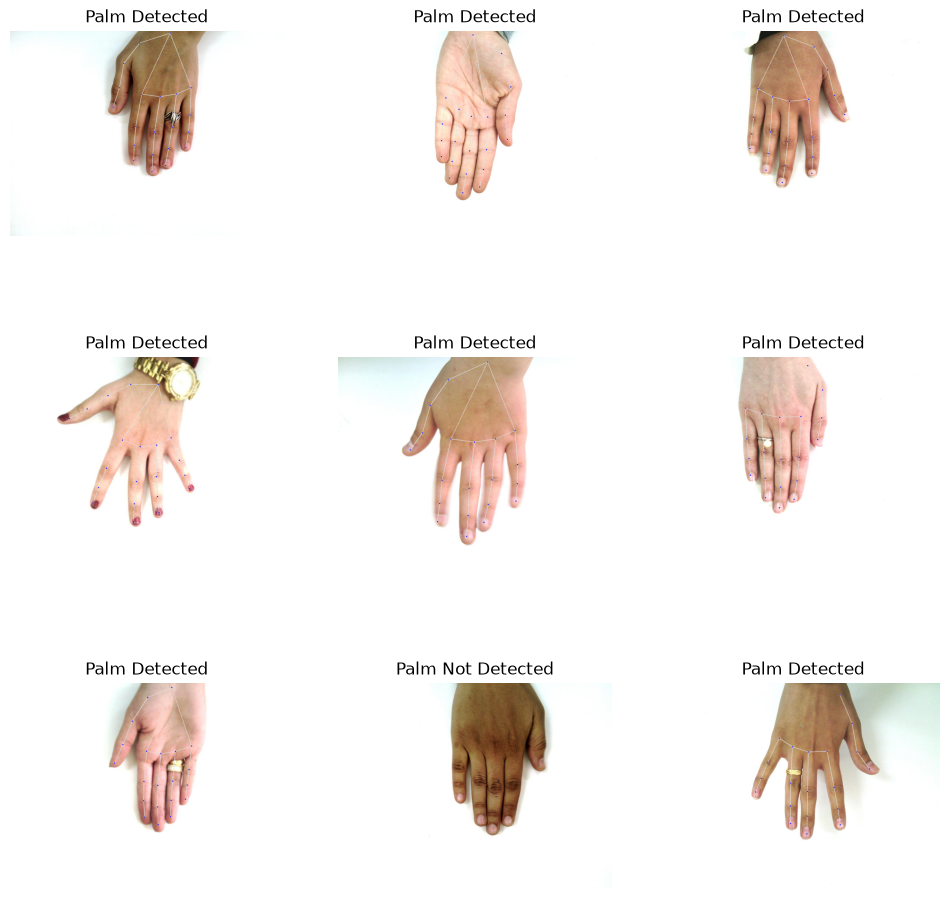

In [21]:
sample_images = image_files[:9]

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(sample_images):
    result, output = detect_palm(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(output)
    plt.axis("off")
    plt.title(result)

plt.show()

# Palm Detection Findings

I tested palm/hand detection using MediaPipe Hands on sample images from the dataset.

## Findings
- MediaPipe successfully detected hand/palm regions in clear images.
- The detector marks hand landmarks such as wrist and finger points.
- Clear images give better detection results.
- Images with poor lighting, unclear hand position, or background noise may need preprocessing.

## Next Step
The next step is to improve preprocessing and extract palm-related features.

# Palm Image Preprocessing

After EDA and initial palm detection, preprocessing is applied to improve image quality before feature extraction.

In [22]:
import cv2
import matplotlib.pyplot as plt

def preprocess_palm_image(image_path):
    image = cv2.imread(image_path)
    
    if image is None:
        return None, None, None, None
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Resize
    resized = cv2.resize(image_rgb, (224, 224))
    
    # Grayscale
    gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
    
    # Histogram equalization for contrast improvement
    enhanced = cv2.equalizeHist(gray)
    
    # Edge detection
    edges = cv2.Canny(enhanced, 50, 150)
    
    return resized, gray, enhanced, edges

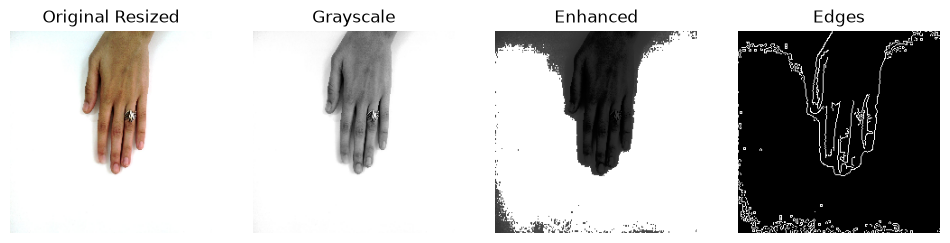

In [23]:
test_image = image_files[0]

resized, gray, enhanced, edges = preprocess_palm_image(test_image)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(resized)
plt.title("Original Resized")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(enhanced, cmap="gray")
plt.title("Enhanced")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.show()

# Preprocessing Findings

## Work Done
- Resized palm images to a fixed size.
- Converted images to grayscale.
- Applied contrast enhancement.
- Applied edge detection to observe palm/hand line structures.

## Findings
- Resizing helps make all images uniform.
- Grayscale conversion reduces image complexity.
- Contrast enhancement improves visibility of hand/palm regions.
- Edge detection helps highlight boundaries and line-like structures.

## Next Step
The next step is palm feature extraction using hand landmarks and image processing techniques.

In [24]:
import math
import pandas as pd

def extract_palm_features(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width, _ = image_rgb.shape

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=1,
        min_detection_confidence=0.5
    ) as hands:

        results = hands.process(image_rgb)

        if not results.multi_hand_landmarks:
            return {
                "image_path": image_path,
                "palm_detected": False
            }

        landmarks = results.multi_hand_landmarks[0].landmark

        wrist = landmarks[0]
        index_mcp = landmarks[5]
        pinky_mcp = landmarks[17]
        middle_tip = landmarks[12]

        wrist_x, wrist_y = wrist.x * width, wrist.y * height
        index_x, index_y = index_mcp.x * width, index_mcp.y * height
        pinky_x, pinky_y = pinky_mcp.x * width, pinky_mcp.y * height
        middle_x, middle_y = middle_tip.x * width, middle_tip.y * height

        palm_width = math.sqrt((index_x - pinky_x)**2 + (index_y - pinky_y)**2)
        hand_length = math.sqrt((middle_x - wrist_x)**2 + (middle_y - wrist_y)**2)

        palm_center_x = (index_x + pinky_x + wrist_x) / 3
        palm_center_y = (index_y + pinky_y + wrist_y) / 3

        return {
            "image_path": image_path,
            "palm_detected": True,
            "image_width": width,
            "image_height": height,
            "palm_width": palm_width,
            "hand_length": hand_length,
            "palm_center_x": palm_center_x,
            "palm_center_y": palm_center_y
        }

In [25]:
features = []

for img_path in image_files[:20]:
    result = extract_palm_features(img_path)
    features.append(result)

features_df = pd.DataFrame(features)
features_df.head()

W0000 00:00:1785051292.883025     484 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051292.899318     484 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051292.952475     488 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051292.969079     488 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051293.023630     492 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785051293.045606     492 inference_feedback_manager.cc:114] Feedback manager 

,image_path,palm_detected,image_width,image_height,palm_width,hand_length,palm_center_x,palm_center_y
0,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,291.229296,816.861327,922.369035,240.409267
1,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,270.277961,925.049438,764.188242,308.178151
2,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,301.834871,859.564160,684.220171,256.553638
3,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,283.819799,814.272263,822.451448,374.884570
4,/kaggle/input/datasets/shyambhu/hands-and-palm...,True,1600.0,1200.0,378.283947,1027.343596,855.833435,313.934600


In [26]:
features_df.describe()

,image_width,image_height,palm_width,hand_length,palm_center_x,palm_center_y
count,19.0,19.0,19.000000,19.000000,19.000000,19.000000
mean,1600.0,1200.0,323.252902,913.629617,790.946512,271.578402
std,0.0,0.0,38.955509,94.600051,100.030885,76.271712
min,1600.0,1200.0,264.726572,801.279998,624.109030,146.122944
25%,1600.0,1200.0,291.635194,822.102331,726.069236,230.137065
50%,1600.0,1200.0,313.735151,902.355675,801.945210,254.011416
75%,1600.0,1200.0,353.749202,976.066338,845.090413,311.056376
max,1600.0,1200.0,385.106627,1089.826499,969.677782,494.048882


# Palm Feature Extraction Findings

I extracted basic palm/hand features using MediaPipe landmarks.

## Work Done
- Detected palm/hand landmarks using MediaPipe.
- Extracted wrist point, index finger base, pinky finger base, and middle finger tip.
- Calculated palm width, hand length, and palm center.

## Findings
- Basic palm geometry can be extracted from clear detected images.
- Palm width and hand length can be used as initial features for palm structure analysis.
- Images where MediaPipe cannot detect the hand need preprocessing or filtering.

## Next Step
The next step is to connect extracted palm features with palmistry-based interpretation logic.

# Final Summary of Current Work

## Work Completed
- Added the given palm and tarot datasets in Kaggle Notebook.
- Connected GPU and verified GPU availability.
- Performed initial EDA on the palm image dataset.
- Displayed sample palm/hand images.
- Checked image file paths, image size, and image format.
- Installed and tested MediaPipe Hands.
- Built an initial palm detector to check whether an image contains a palm/hand.
- Applied basic preprocessing such as resizing, grayscale conversion, contrast enhancement, and edge detection.
- Extracted basic palm/hand features using MediaPipe landmarks.

## Key Findings
- The palm dataset contains usable hand/palm images for preprocessing and feature extraction.
- MediaPipe successfully detects clear palm/hand images.
- Hand landmarks can be used to extract palm width, hand length, palm center, wrist point, and finger points.
- Some images may need preprocessing because detection can be affected by lighting, background, and hand position.
